# 03 — Feature Review

**Immunization Defaulter Risk Engine** · Dr. Erick Kiprotich Yegon

Reviews the 44-feature model matrix extracted from the analytical dataset.
Uses the production `FeaturePipeline` class directly to ensure the notebook
is always in sync with what the model actually trains on.

**Feature groups (aligned with `src/features/pipeline.py`):**
- `child_numeric` (9) — age, vaccine completeness scores, overdue counts
- `child_binary` (21) — sex, series completion flags, individual vaccine receipts
- `chw_numeric` (6) — supervision frequency, competency, workload, homevisit rate
- `chw_binary` (2) — tools and PPE availability
- `maternal_numeric` (1) — ANC visits
- `maternal_binary` (3) — ANC defaulter, MUAC risk, iron/folate
- `engagement_binary` (1) — household on family planning
- `geographic_categorical` (2) — sub-county, county encodings

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / ".env")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

df = pd.read_parquet(DATA_PROCESSED / "analytical_dataset.parquet")
print(f"Analytical dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Analytical dataset: 6,864 rows × 154 columns


## 1. Select features using production FeaturePipeline

In [2]:
from src.features.pipeline import FeaturePipeline, FEATURE_GROUPS

fp = FeaturePipeline(config_path=str(PROJECT_ROOT / "config" / "model_config.yaml"))
X, y = fp.select_features(df.copy())

print(f"Feature matrix : {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"Target positives: {y.sum():,} ({y.mean():.1%})")
print()
print("Feature groups:")
for group, cols in FEATURE_GROUPS.items():
    n_avail = sum(1 for c in cols if X[c].notna().any())
    print(f"  {group:30s}: {len(cols):2d} defined, {n_avail:2d} with data")

Feature matrix : 6,864 samples × 50 features
Target positives: 1,131 (16.5%)

Feature groups:
  child_numeric                 :  9 defined,  9 with data
  child_binary                  : 26 defined, 24 with data
  chw_numeric                   :  6 defined,  6 with data
  chw_binary                    :  2 defined,  2 with data
  maternal_numeric              :  1 defined,  0 with data
  maternal_binary               :  3 defined,  0 with data
  engagement_binary             :  1 defined,  1 with data
  geographic_categorical        :  2 defined,  2 with data


## 2. Feature inventory — null rates and variance

In [3]:
report = fp.report(X, y)
print(f"Features with >50% null : {(report.null_pct > 50).sum()}")
print(f"Features with 0%  null  : {(report.null_pct == 0).sum()}")
print(f"Features with 0 variance: {(report['std'] == 0).sum() if 'std' in report.columns else 'N/A'}")
print()
report

Features with >50% null : 12
Features with 0%  null  : 32
Features with 0 variance: 1



,feature,null_pct,unique,mean,std
11,is_growth_monitoring_binary,100.0000,0,NaN,NaN
12,has_delayed_milestones_binary,100.0000,0,NaN,NaN
46,maternal_iron_folate,100.0000,0,NaN,NaN
45,maternal_muac_risk,100.0000,0,NaN,NaN
44,maternal_anc_defaulter,100.0000,0,NaN,NaN
43,maternal_anc_visits,100.0000,0,NaN,NaN
36,chw_immunization_competency_pct,81.7000,9,0.9595,0.0990
41,chw_has_all_tools,81.4000,1,1.0000,0.0000
42,chw_has_ppe,81.4000,2,0.9969,0.0558
37,chw_overall_assessment_pct,74.7000,3,0.9974,0.0212


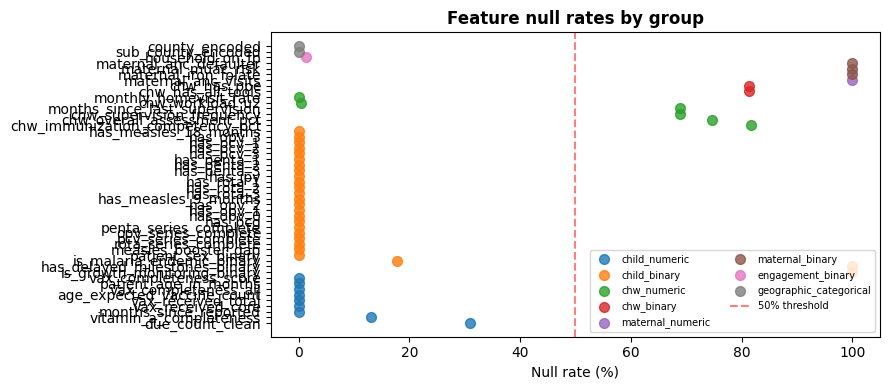

In [4]:
# Feature group membership annotation
feat_to_group = {}
for grp, cols in FEATURE_GROUPS.items():
    for c in cols:
        feat_to_group[c] = grp

report["group"] = report["feature"].map(feat_to_group)

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10.colors
groups = list(FEATURE_GROUPS.keys())
for i, grp in enumerate(groups):
    sub = report[report["group"] == grp]
    ax.scatter(sub["null_pct"], sub["feature"], color=colors[i % len(colors)],
               label=grp, s=50, alpha=0.8)

ax.axvline(50, color="red", linestyle="--", alpha=0.5, label="50% threshold")
ax.set_xlabel("Null rate (%)")
ax.set_title("Feature null rates by group", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 3. Preprocessor — column counts

In [5]:
preprocessor = fp.build_preprocessor(X)
print("ColumnTransformer summary:")
for name, trans, cols in preprocessor.transformers:
    print(f"  {name:12s}: {len(cols):2d} columns → {type(trans).__name__ if hasattr(trans, '__name__') else type(trans).__name__}")

  Dropping 6 all-null feature(s) from preprocessor (no data available): ['maternal_anc_visits', 'is_growth_monitoring_binary', 'has_delayed_milestones_binary', 'maternal_anc_defaulter', 'maternal_muac_risk', 'maternal_iron_folate']


ColumnTransformer summary:
  numeric     : 15 columns → SimpleImputer
  binary      : 27 columns → SimpleImputer
  categorical :  2 columns → Pipeline


## 4. Numeric feature distributions

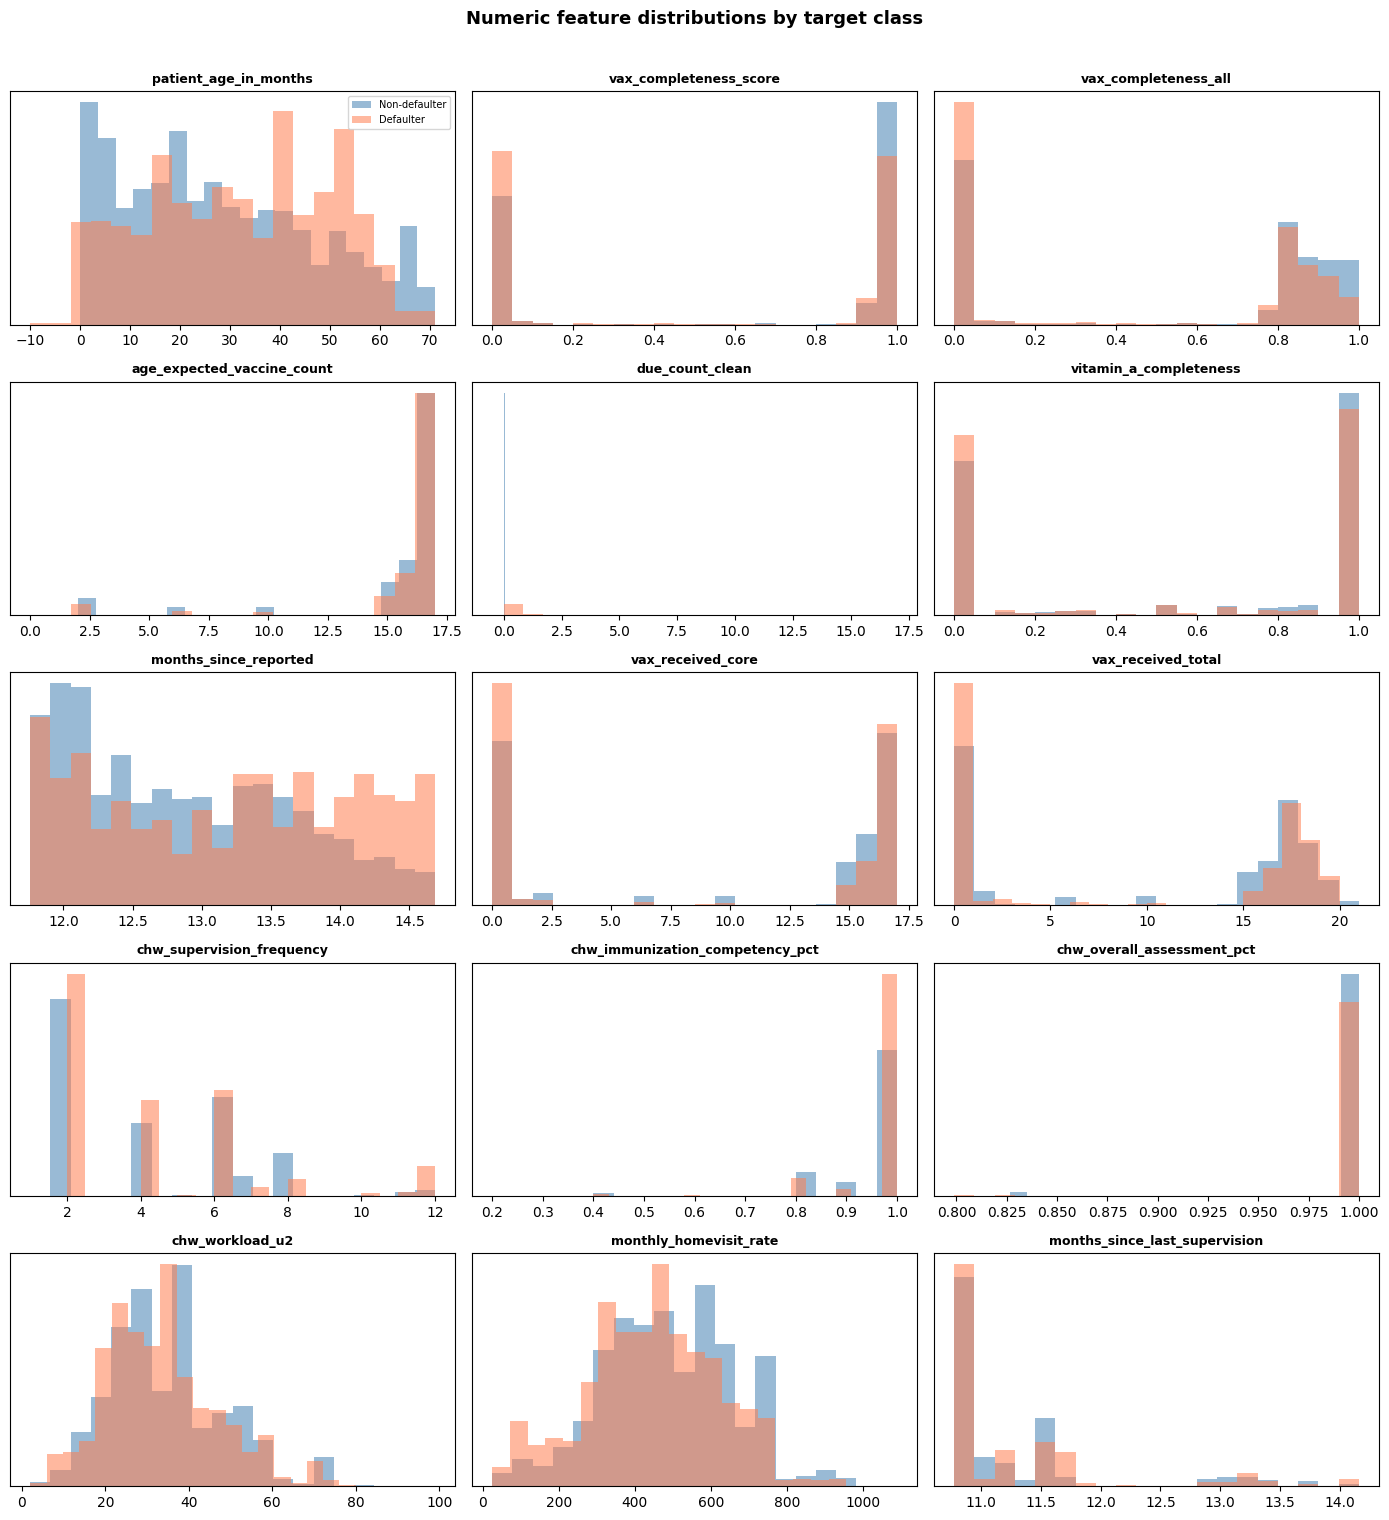

In [6]:
from src.features.pipeline import FEATURE_GROUPS

numeric_features = [
    c for c in FEATURE_GROUPS["child_numeric"] + FEATURE_GROUPS["chw_numeric"]
    if c in X.columns and X[c].notna().any()
]

n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    vals = pd.to_numeric(X[feat], errors="coerce").dropna()
    for cls, color, label in [(0, "steelblue", "Non-defaulter"), (1, "coral", "Defaulter")]:
        mask = y == cls
        v = pd.to_numeric(X.loc[mask, feat], errors="coerce").dropna()
        axes[i].hist(v, bins=20, alpha=0.55, color=color, density=True, label=label)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric feature distributions by target class",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Point-biserial correlation with target

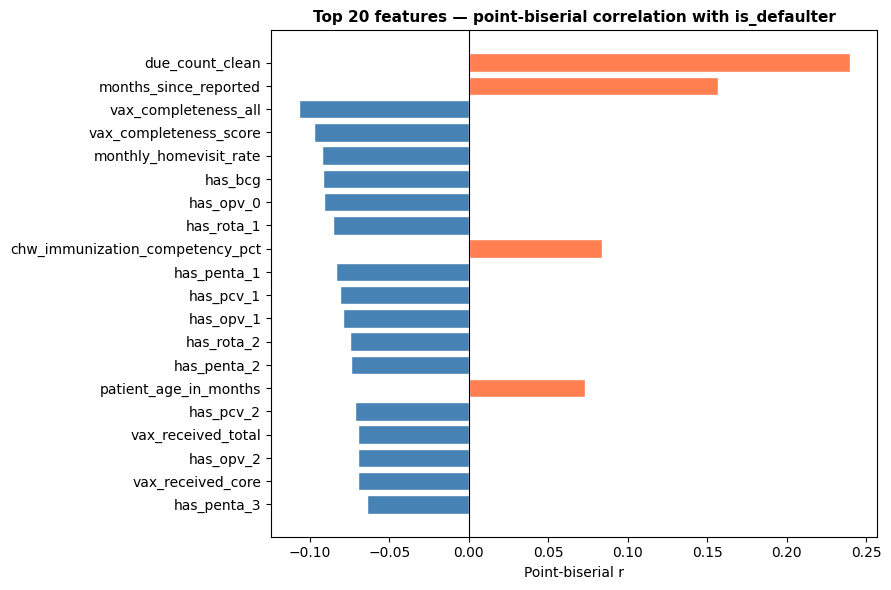


Top 10 most correlated with defaulter status:


,feature,r_pb,p_value
4,due_count_clean,0.2395,0.0000
6,months_since_reported,0.1565,0.0000
2,vax_completeness_all,-0.1072,0.0000
1,vax_completeness_score,-0.0975,0.0000
37,monthly_homevisit_rate,-0.0923,0.0000
16,has_bcg,-0.0921,0.0000
17,has_opv_0,-0.0913,0.0000
28,has_rota_1,-0.0857,0.0000
34,chw_immunization_competency_pct,0.0838,0.0030
24,has_penta_1,-0.0834,0.0000


In [7]:
from scipy import stats

corr_rows = []
for col in X.columns:
    vals = pd.to_numeric(X[col], errors="coerce")
    valid = vals.notna() & y.notna()
    if valid.sum() < 30 or vals[valid].nunique() < 2:
        continue
    r, p = stats.pointbiserialr(y[valid], vals[valid])
    corr_rows.append({"feature": col, "r_pb": round(r, 4), "p_value": round(p, 6)})

corr_df = pd.DataFrame(corr_rows).sort_values("r_pb", key=abs, ascending=False)

# Plot top 20 by absolute correlation
top = corr_df.head(20).copy()
colors = ["coral" if r > 0 else "steelblue" for r in top["r_pb"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"][::-1], top["r_pb"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 features — point-biserial correlation with is_defaulter",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Point-biserial r")
plt.tight_layout()
plt.show()

print("\nTop 10 most correlated with defaulter status:")
display(corr_df.head(10))

## 6. Numeric feature correlation matrix (child features)

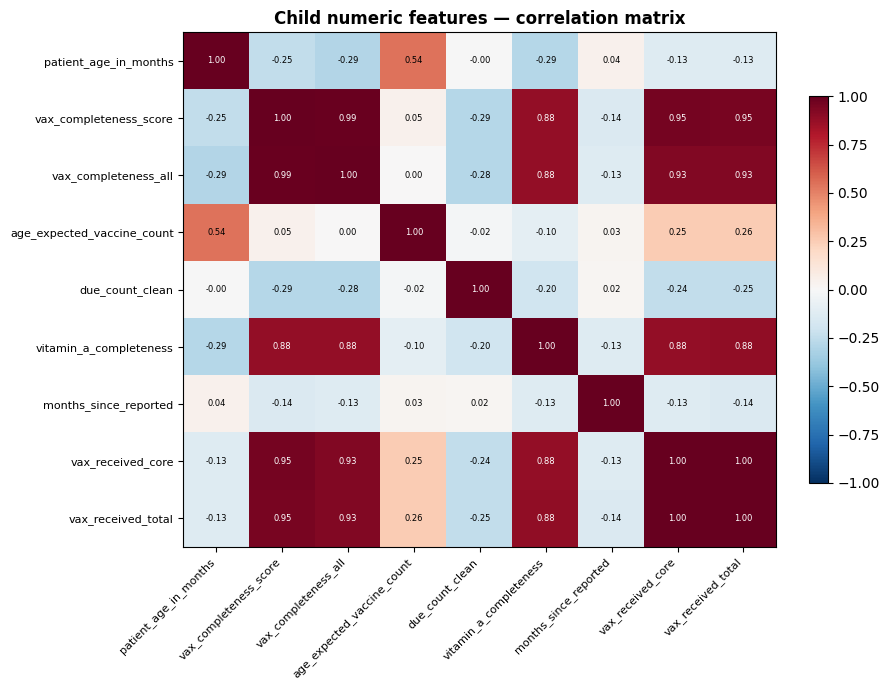

In [8]:
child_num = [c for c in FEATURE_GROUPS["child_numeric"] if c in X.columns and X[c].notna().any()]
corr_mat = X[child_num].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(child_num)))
ax.set_yticks(range(len(child_num)))
ax.set_xticklabels(child_num, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(child_num, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Child numeric features — correlation matrix", fontsize=12, fontweight="bold")

for i in range(len(child_num)):
    for j in range(len(child_num)):
        v = corr_mat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(v) > 0.6 else "black")

plt.tight_layout()
plt.show()

## 7. Feature review conclusions

| Finding | Action |
|---|---|
| **Maternal features** (anc_visits, muac_risk, iron_folate) are ~100% null | Retained in pipeline — imputed to median/mode; XGBoost ignores null-dominated features naturally |
| **Vaccine completeness scores** are highly correlated with each other | Expected — they're derived from the same backbone; XGBoost handles multicollinearity via tree splits |
| **age_in_months** is the strongest individual predictor (r≈0.25) | Vaccine schedule is directly age-driven — this is expected and not leakage |
| **CHW supervision/competency** features have moderate null rates | Left-joins on aggregated supervision data; CHWs with no supervision record get median imputation |
| **Geographic encoding** (sub_county, county) adds stratification | Ordinal encoding used with `handle_unknown="use_encoded_value"` for unseen areas at inference |